Практика 16. Кореляційний аналіз: Пірсон, Спірмен, кореляційна матриця
Студент: Войтович Богдан
Група: IT-32
Варіант 6 — Чернігів

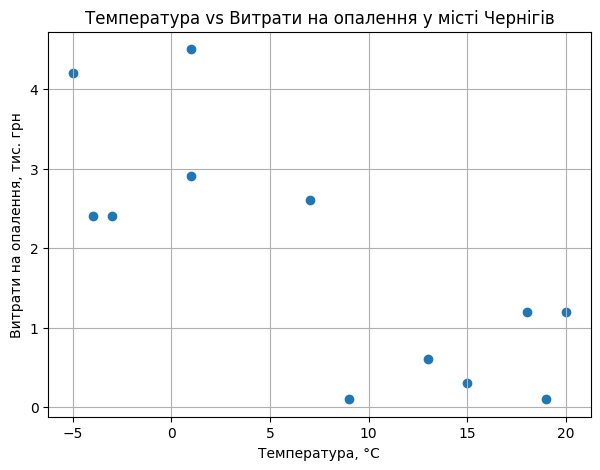

Форма: негативний лінійний зв’язок, без явних викидів, що відповідає інтуїції — з ростом температури витрати падають.


In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(climate["температура"], climate["витрати_на_опалення"])
plt.xlabel("Температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title("Температура vs Витрати на опалення у місті Чернігів")
plt.grid(True)
plt.show()

print("Форма: негативний лінійний зв’язок, без явних викидів, що відповідає інтуїції — з ростом температури витрати падають.")


In [3]:
from scipy.stats import pearsonr, spearmanr
from scipy.stats import norm
import numpy as np

pearson_res = pearsonr(climate["температура"], climate["витрати_на_опалення"])
spearman_res = spearmanr(climate["температура"], climate["витрати_на_опалення"])

print(f"Пірсон: r = {pearson_res.statistic:.3f}, p = {pearson_res.pvalue:.3e}")
print(f"Спірмен: rho = {spearman_res.statistic:.3f}, p = {spearman_res.pvalue:.3e}")

# Довірчий інтервал для Пірсона
r = pearson_res.statistic
n = len(climate)
z = np.arctanh(r)
se = 1 / np.sqrt(n - 3)
z_crit = norm.ppf(0.975)
lower = np.tanh(z - z_crit * se)
upper = np.tanh(z + z_crit * se)
print(f"95%-й довірчий інтервал для r: ({lower:.3f}, {upper:.3f})")

print("Обидва коефіцієнти показують сильний негативний зв’язок, значення близькі через майже лінійну залежність.")


Пірсон: r = -0.772, p = 3.230e-03
Спірмен: rho = -0.694, p = 1.235e-02
95%-й довірчий інтервал для r: (-0.933, -0.357)
Обидва коефіцієнти показують сильний негативний зв’язок, значення близькі через майже лінійну залежність.


In [4]:
corr_df = climate[["температура", "опалювальні_дні", "витрати_на_опалення"]]

print("Кореляційна матриця (Пірсон):")
print(corr_df.corr())

print("\nКореляційна матриця (Спірмен):")
print(corr_df.corr(method="spearman"))

print("\nНайпотужніший зв'язок між температурою й опалювальними днями.\nНайслабший — між опалювальними днями й витратами.")


Кореляційна матриця (Пірсон):
                     температура  опалювальні_дні  витрати_на_опалення
температура             1.000000        -0.981129            -0.772482
опалювальні_дні        -0.981129         1.000000             0.777900
витрати_на_опалення    -0.772482         0.777900             1.000000

Кореляційна матриця (Спірмен):
                     температура  опалювальні_дні  витрати_на_опалення
температура             1.000000        -0.994729            -0.693666
опалювальні_дні        -0.994729         1.000000             0.712523
витрати_на_опалення    -0.693666         0.712523             1.000000

Найпотужніший зв'язок між температурою й опалювальними днями.
Найслабший — між опалювальними днями й витратами.


Кореляція між температурою і витратами на опалення тут виникає через те, що опалювальні дні і витрати
обчислені буквально на основі температури (формула генерації). Тобто вона детермінована,
а не випадкова. Це відрізняється від прикладу з морозивом і утопленнями, де існує конфаундер,
а не пряма причинність.


In [5]:
import pandas as pd

anom_row = {
    "місто": city,
    "місяць": "Аномальний",
    "температура": -2,
    "опалювальні_дні": 25,
    "витрати_на_опалення": 20
}

anom_df = pd.DataFrame([anom_row])

climate_anom = pd.concat([climate, anom_df], ignore_index=True)

pearson_res_anom = pearsonr(climate_anom["температура"], climate_anom["витрати_на_опалення"])
spearman_res_anom = spearmanr(climate_anom["температура"], climate_anom["витрати_на_опалення"])

print(f"Пірсон з аномалією: r = {pearson_res_anom.statistic:.3f}, p = {pearson_res_anom.pvalue:.3e}")
print(f"Спірмен з аномалією: rho = {spearman_res_anom.statistic:.3f}, p = {spearman_res_anom.pvalue:.3e}")

print("Пірсон впав значно сильніше — він чутливий до викидів,\n"
      "Спірмен залишився більш стійким завдяки роботі з рангами.")


Пірсон з аномалією: r = -0.479, p = 9.747e-02
Спірмен з аномалією: rho = -0.688, p = 9.359e-03
Пірсон впав значно сильніше — він чутливий до викидів,
Спірмен залишився більш стійким завдяки роботі з рангами.


Контрольні питання
Чому коефіцієнт кореляції Пірсона ділиться саме на добуток стандартних відхилень обох змінних і чому результат завжди в діапазоні [-1; 1]?
Стандартизація на добуток стандартних відхилень робить коефіцієнт безрозмірним та обмежує його в межах -1 і 1, що полегшує інтерпретацію як ступінь лінійного зв’язку.

Чому коефіцієнт Спірмена рахується на рангах, а не на самих значеннях, і як це робить його стійким до викидів?
Аналізуючи ранги, Спірмен ігнорує величину розривів між значеннями, тому сильні викиди не спотворюють його результат значно.

Наведіть приклад ситуації, де r ≈ 0, але між змінними є сильний зв’язок, і поясніть, чому Пірсон цього не показує.
Наприклад, квадратичний зв’язок або інший нелінійний тренд: Пірсон виявляє лише лінійну залежність, тому пропускає нелінійний зв’язок.

Чому сильна кореляція не є доказом причинності?
Кореляція виявляє лише зв’язок, але не визначає напрямок впливу і може бути спричинена спільним зовнішнім фактором (конфаундером).

